# Comparaison 6 modèles — Dataset 2 Equipment Monitoring — by_equipment

| Champ | Valeur |
|-------|--------|
| **Scénario** | by_equipment : Pump → Turbine → Compressor (3 tâches) |
| **Modèles** | TinyOL · EWC · HDC · KMeans · Mahalanobis · DBSCAN |
| **Dataset** | equipment_anomaly_data.csv — 7 672 échantillons |
| **Sprint** | 7 — S7-13 |

Ce notebook agrège les résultats des expériences **exp_011, exp_001, exp_002, exp_005, exp_007, exp_008**.
Il constitue le support de présentation principal pour les réunions d'encadrement.

**Figures générées** :
1. `radar_comparison.png` — radar 5-axes (AA, Stabilité, BWT, RAM, Vitesse)
2. `barplot_aa_comparison.png` — barplot AA/AF/BWT pour les 6 modèles
3. `acc_matrix_grid.png` — grille 2×3 des matrices d'accuracy
4. `scatter_ram_vs_accuracy.png` — trade-off RAM/performance (Gap 2, budget STM32 ≤ 64 Ko)
5. `scatter_flops_vs_accuracy.png` — coût de calcul portable (MACs, indépendant de la machine)
6. `scatter_latency_vs_accuracy.png` — latence PC (budget 100 ms, ⚠ non transférable au MCU)

In [1]:
# Section 1 — Setup + chargement normalisé des 6 modèles
import json
import os
import sys
from datetime import datetime
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display

# --- CWD navigation ---
_cwd = Path(".").resolve()
if _cwd.name == "monitoring_by_equipment":
    os.chdir(_cwd.parent.parent.parent)
elif _cwd.name == "cl_eval":
    os.chdir(_cwd.parent.parent)
elif _cwd.name == "notebooks":
    os.chdir(_cwd.parent)
REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.evaluation.plots import (
    plot_metrics_comparison, plot_model_radar, save_figure,
)
from src.evaluation.compute_cost import compute_macs

FIGURES_DIR = REPO_ROOT / "notebooks/figures/cl_evaluation/comparison/monitoring/by_equipment"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TASK_NAMES = ["Pump", "Turbine", "Compressor"]
MODEL_ORDER = ["TinyOL", "EWC", "HDC", "KMeans", "Mahalanobis", "DBSCAN"]

# Chemins d'expériences (chemins réels, pas ceux des specs obsolètes)
MODEL_EXP_MAP = {
    "TinyOL":      ("exp_011_tinyol_monitoring_by_equipment",      "metrics.json",                         None),
    "EWC":         ("exp_001_ewc_monitoring_by_equipment",         "metrics.json",                         "acc_matrix_ewc.npy"),
    "HDC":         ("exp_002_hdc_monitoring_by_equipment",         "metrics.json",                         "acc_matrix_hdc.npy"),
    "KMeans":      ("exp_005_unsupervised_monitoring_by_equipment","metrics_kmeans.json",                  "acc_matrix_kmeans.npy"),
    "Mahalanobis": ("exp_007_mahalanobis_monitoring_by_equipment", "metrics_mahalanobis_dataset2.json",    "acc_matrix_mahalanobis_dataset2.npy"),
    "DBSCAN":      ("exp_008_dbscan_monitoring_by_equipment",      "metrics_dbscan_dataset2.json",         "acc_matrix_dbscan_dataset2.npy"),
}

BASE = REPO_ROOT / "experiments"


def normalize_metrics(raw: dict, model_name: str) -> dict:
    """Normalise les différents schémas de metrics.json vers un dict commun.

    Clés retournées : aa, af, bwt, ram_peak_bytes, inference_latency_ms, n_params, auroc_avg.
    """
    if model_name == "TinyOL":
        # Structure plate avec clés acc_final / avg_forgetting / backward_transfer
        return {
            "aa":  raw["acc_final"],
            "af":  raw["avg_forgetting"],
            "bwt": raw["backward_transfer"],
            "ram_peak_bytes": raw["ram_peak_bytes"],
            "inference_latency_ms": raw["inference_latency_ms"],
            "n_params": raw.get("n_params_encoder", 184) + raw.get("n_params_oto", 10),
            "auroc_avg": None,
        }
    if model_name == "EWC":
        cl = raw["cl_metrics"]["ewc"]
        mem = raw["cl_metrics"]["memory"]["forward"]
        return {
            "aa": cl["aa"], "af": cl["af"], "bwt": cl["bwt"],
            "ram_peak_bytes": mem["ram_peak_bytes"],
            "inference_latency_ms": mem["inference_latency_ms"],
            "n_params": mem["n_params"],
            "auroc_avg": None,
        }
    if model_name == "HDC":
        cl = raw["cl_metrics"]
        return {
            "aa": cl["aa"], "af": cl["af"], "bwt": cl["bwt"],
            "ram_peak_bytes": cl["ram_peak_bytes"],
            "inference_latency_ms": cl["inference_latency_ms"],
            "n_params": cl.get("n_params", 2048),
            "auroc_avg": None,
        }
    # KMeans / Mahalanobis / DBSCAN
    if "cl_metrics" in raw:  # KMeans
        cl = raw["cl_metrics"]
        mem = cl.get("memory", {})
        return {
            "aa": cl["aa"], "af": cl["af"], "bwt": cl["bwt"],
            "ram_peak_bytes": mem.get("ram_peak_bytes", 0),
            "inference_latency_ms": mem.get("inference_latency_ms", 0.0),
            "n_params": mem.get("n_params", 0),
            "auroc_avg": cl.get("auroc_avg"),
        }
    # Mahalanobis / DBSCAN — structure plate
    return {
        "aa": raw["aa"], "af": raw["af"], "bwt": raw["bwt"],
        "ram_peak_bytes": raw["ram_peak_bytes"],
        "inference_latency_ms": raw["inference_latency_ms"],
        "n_params": raw.get("n_params", 0),
        "auroc_avg": raw.get("auroc_avg"),
    }


def load_acc_matrix(model_name: str, raw: dict, npy_file: str | None, exp_dir: Path) -> np.ndarray:
    """Charge la matrice d'accuracy 3×3 (NaN pour upper-triangle)."""
    if npy_file is not None:
        arr = np.load(exp_dir / npy_file, allow_pickle=True)
        # Si c'est une liste de listes JSON (cas DBSCAN), reconvertir proprement
        return np.array(arr, dtype=float)
    # TinyOL : acc_matrix embedded lower-triangular dans le JSON
    raw_mat = raw["acc_matrix"]
    n = len(raw_mat)
    mat = np.full((n, n), np.nan, dtype=float)
    for i, row in enumerate(raw_mat):
        for j, v in enumerate(row):
            if v is not None:
                mat[i, j] = v
    return mat


# Chargement des 6 modèles
results = {}
acc_matrices = {}

for model in MODEL_ORDER:
    exp_dir_name, metrics_file, npy_file = MODEL_EXP_MAP[model]
    exp_dir = BASE / exp_dir_name / "results"
    raw = json.loads((exp_dir / metrics_file).read_text())
    results[model] = normalize_metrics(raw, model)
    acc_matrices[model] = load_acc_matrix(model, raw, npy_file, exp_dir)
    r = results[model]
    auroc_s = f"{r['auroc_avg']:.4f}" if r['auroc_avg'] is not None else "—"
    print(f"{model:12s} → AA={r['aa']:.4f} AF={r['af']:.4f} BWT={r['bwt']:+.4f} "
          f"RAM={r['ram_peak_bytes']/1024:5.1f}Ko lat={r['inference_latency_ms']:.5f}ms "
          f"n_params={r['n_params']} AUROC={auroc_s}")

print(f"\n6 modèles chargés | Date exécution : {datetime.now():%Y-%m-%d %H:%M}")

TinyOL       → AA=0.9123 AF=0.0079 BWT=-0.0029 RAM=  4.3Ko lat=0.00975ms n_params=194 AUROC=—
EWC          → AA=0.9824 AF=0.0010 BWT=+0.0000 RAM=  1.1Ko lat=0.03580ms n_params=705 AUROC=—
HDC          → AA=0.8698 AF=0.0000 BWT=+0.0019 RAM= 14.2Ko lat=0.04758ms n_params=2048 AUROC=—
KMeans       → AA=0.9433 AF=0.0049 BWT=-0.0040 RAM=  5.2Ko lat=0.39870ms n_params=8 AUROC=0.9621
Mahalanobis  → AA=0.9524 AF=0.0010 BWT=-0.0010 RAM=  1.5Ko lat=0.01801ms n_params=20 AUROC=0.9718
DBSCAN       → AA=0.9557 AF=0.0000 BWT=+0.0010 RAM= 71.9Ko lat=0.42320ms n_params=5412 AUROC=0.9786

6 modèles chargés | Date exécution : 2026-04-21 09:53


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/monitoring/by_equipment/radar_comparison.png


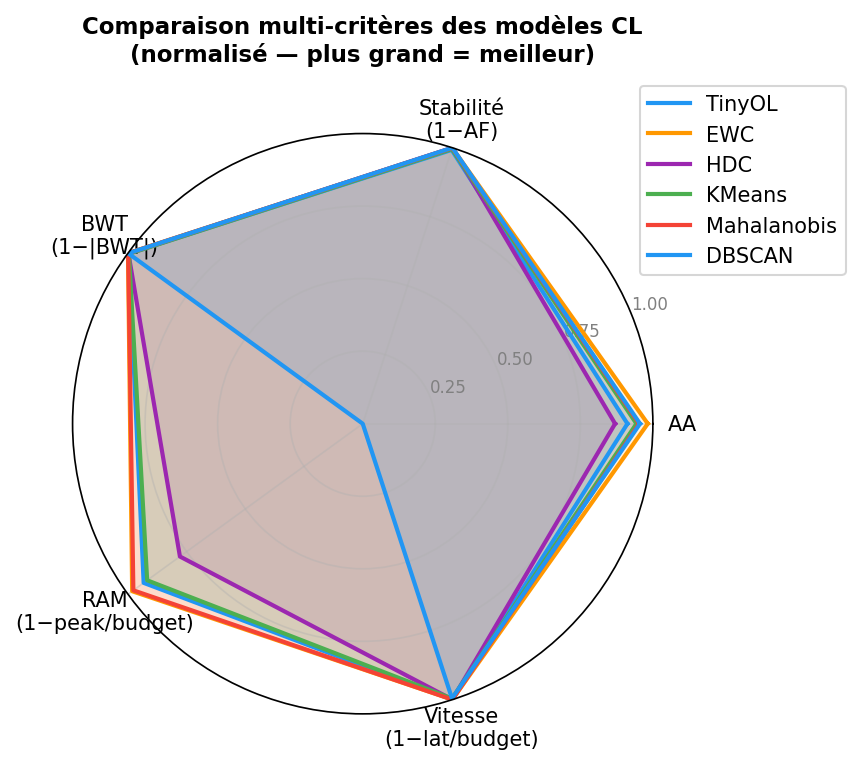

In [2]:
# Section 2 — Radar multi-critères (6 modèles, 5 axes normalisés)
# Axes : AA, Stabilité (1−AF), BWT neutre (1−|BWT|), RAM (1−peak/64Ko), Vitesse (1−lat/100ms)

fig = plot_model_radar(results, ram_budget_bytes=65536.0, latency_budget_ms=100.0)
save_figure(fig, FIGURES_DIR / "radar_comparison.png")
display(Image(str(FIGURES_DIR / "radar_comparison.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/monitoring/by_equipment/barplot_aa_comparison.png


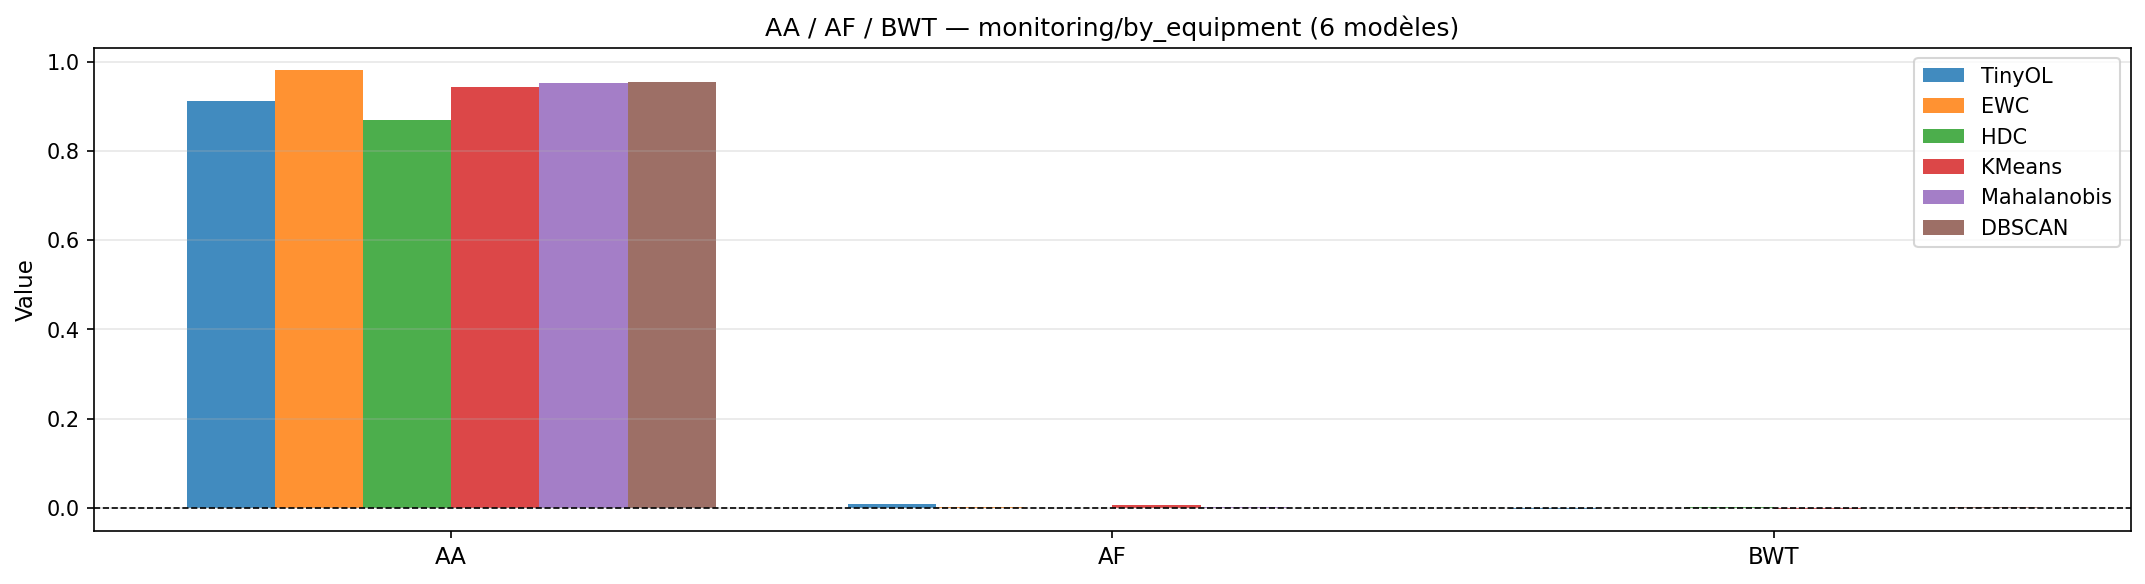

In [3]:
# Section 3 — Barplot AA/AF/BWT groupé (6 modèles)

fig = plot_metrics_comparison(
    results,
    metrics=["aa", "af", "bwt"],
    title="AA / AF / BWT — monitoring/by_equipment (6 modèles)",
)
save_figure(fig, FIGURES_DIR / "barplot_aa_comparison.png")
display(Image(str(FIGURES_DIR / "barplot_aa_comparison.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/monitoring/by_equipment/acc_matrix_grid.png


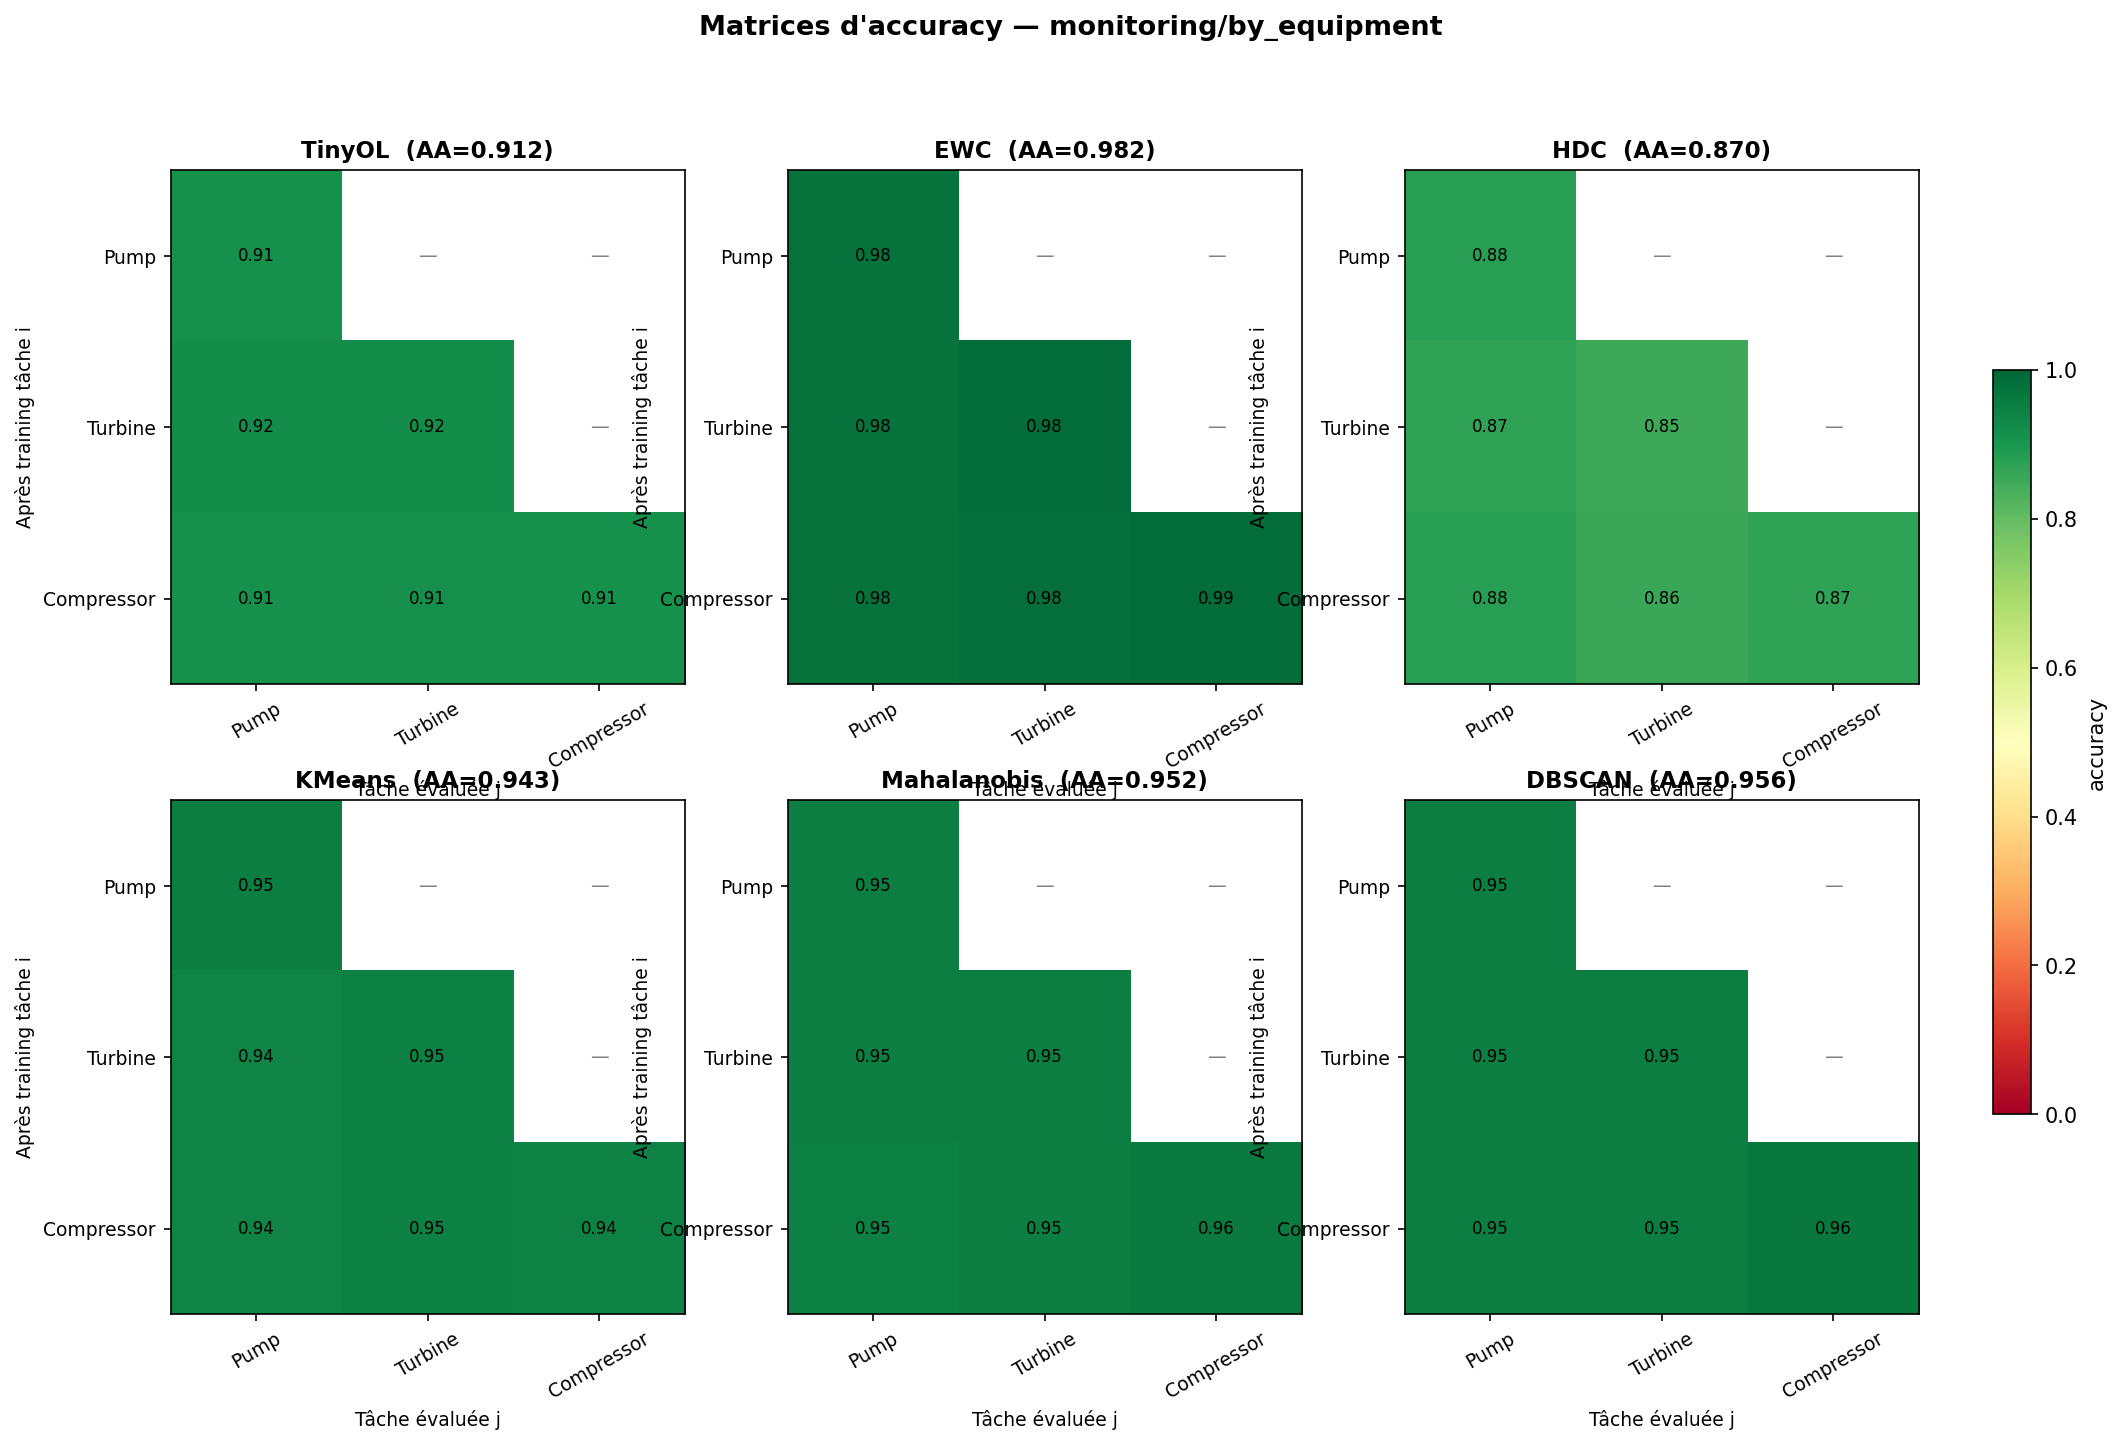

In [4]:
# Section 4 — Grille 2×3 des matrices d'accuracy des 6 modèles

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
cmap = plt.get_cmap("RdYlGn")

for ax, model in zip(axes.flat, MODEL_ORDER):
    acc_mat = acc_matrices[model]
    masked = np.ma.masked_invalid(acc_mat)
    im = ax.imshow(masked, vmin=0, vmax=1, cmap=cmap)
    ax.set_title(f"{model}  (AA={results[model]['aa']:.3f})", fontsize=11, fontweight="bold")
    ax.set_xticks(range(len(TASK_NAMES)))
    ax.set_yticks(range(len(TASK_NAMES)))
    ax.set_xticklabels(TASK_NAMES, rotation=30, fontsize=9)
    ax.set_yticklabels(TASK_NAMES, fontsize=9)
    ax.set_xlabel("Tâche évaluée j", fontsize=9)
    ax.set_ylabel("Après training tâche i", fontsize=9)
    # Annoter chaque cellule
    for i in range(acc_mat.shape[0]):
        for j in range(acc_mat.shape[1]):
            v = acc_mat[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                        color="black" if v > 0.5 else "white")
            else:
                ax.text(j, i, "—", ha="center", va="center", fontsize=9, color="grey")

fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.02, pad=0.04, label="accuracy")
fig.suptitle("Matrices d'accuracy — monitoring/by_equipment", fontsize=13, fontweight="bold")
save_figure(fig, FIGURES_DIR / "acc_matrix_grid.png")
display(Image(str(FIGURES_DIR / "acc_matrix_grid.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/monitoring/by_equipment/scatter_ram_vs_accuracy.png


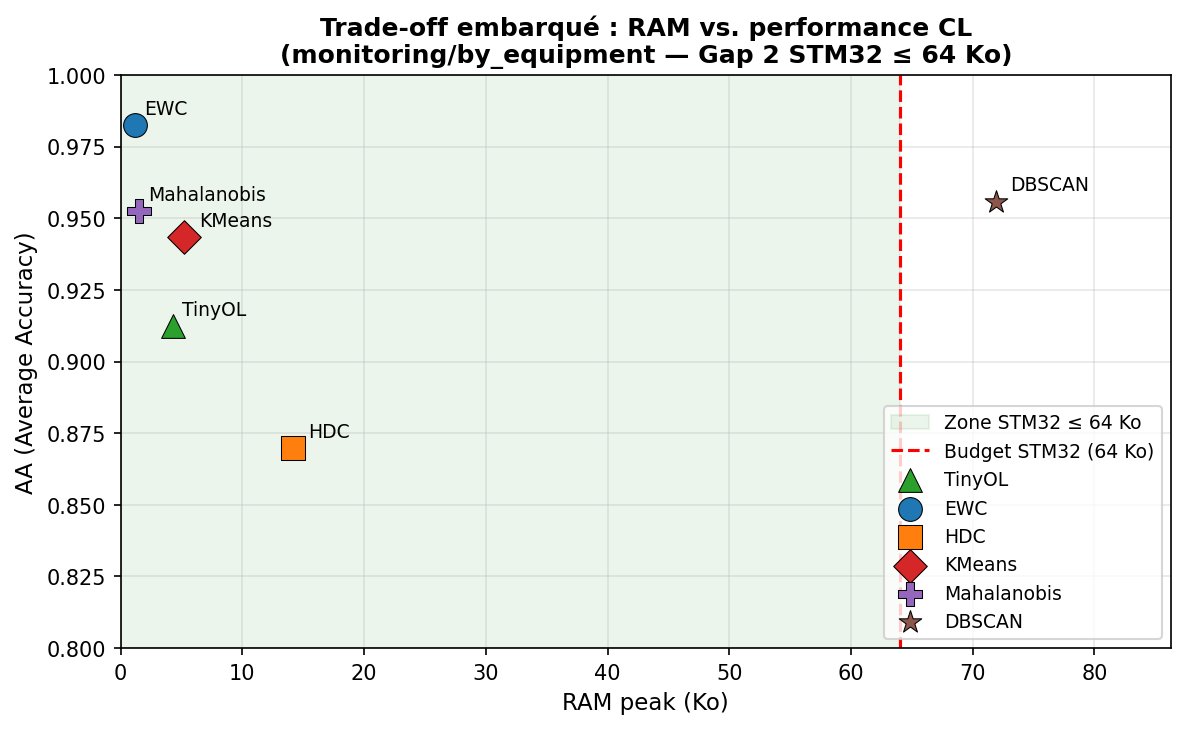

In [5]:
# Section 5a — Scatter RAM peak vs. accuracy (Gap 2 — STM32 ≤ 64 Ko)
# Format cohérent avec notebooks/cl_eval/baselines/monitoring_single_task.ipynb (cell-6)

STM32_RAM_LIMIT_KB = 64.0

SCATTER_MARKERS: dict[str, tuple[str, str]] = {
    "EWC":         ("o", "#1f77b4"),
    "HDC":         ("s", "#ff7f0e"),
    "TinyOL":      ("^", "#2ca02c"),
    "KMeans":      ("D", "#d62728"),
    "Mahalanobis": ("P", "#9467bd"),
    "DBSCAN":      ("*", "#8c564b"),
}

fig, ax = plt.subplots(figsize=(8, 5))

# Zone budget STM32
ax.axvspan(0, STM32_RAM_LIMIT_KB, alpha=0.08, color="green",
           label=f"Zone STM32 ≤ {STM32_RAM_LIMIT_KB:.0f} Ko")
ax.axvline(STM32_RAM_LIMIT_KB, color="red", linestyle="--", linewidth=1.5,
           label=f"Budget STM32 ({STM32_RAM_LIMIT_KB:.0f} Ko)")

for name in MODEL_ORDER:
    r = results[name]
    ram_kb = r["ram_peak_bytes"] / 1024
    acc    = r["aa"]
    marker, color = SCATTER_MARKERS[name]
    ax.scatter(ram_kb, acc, marker=marker, color=color, s=130, zorder=5, label=name,
               edgecolor="black", linewidth=0.5)
    x_offset = 0.8 if ram_kb < 5 else 1.2
    ax.annotate(name, xy=(ram_kb, acc), xytext=(ram_kb + x_offset, acc + 0.004),
                fontsize=9)

max_ram_kb = max(r["ram_peak_bytes"] for r in results.values()) / 1024
ax.set_xlabel("RAM peak (Ko)", fontsize=11)
ax.set_ylabel("AA (Average Accuracy)", fontsize=11)
ax.set_title(
    "Trade-off embarqué : RAM vs. performance CL\n(monitoring/by_equipment — Gap 2 STM32 ≤ 64 Ko)",
    fontsize=12, fontweight="bold",
)
ax.set_xlim(0, max_ram_kb * 1.2)
ax.set_ylim(0.80, 1.0)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
fig.tight_layout()

save_figure(fig, FIGURES_DIR / "scatter_ram_vs_accuracy.png")
display(Image(str(FIGURES_DIR / "scatter_ram_vs_accuracy.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/monitoring/by_equipment/scatter_flops_vs_accuracy.png


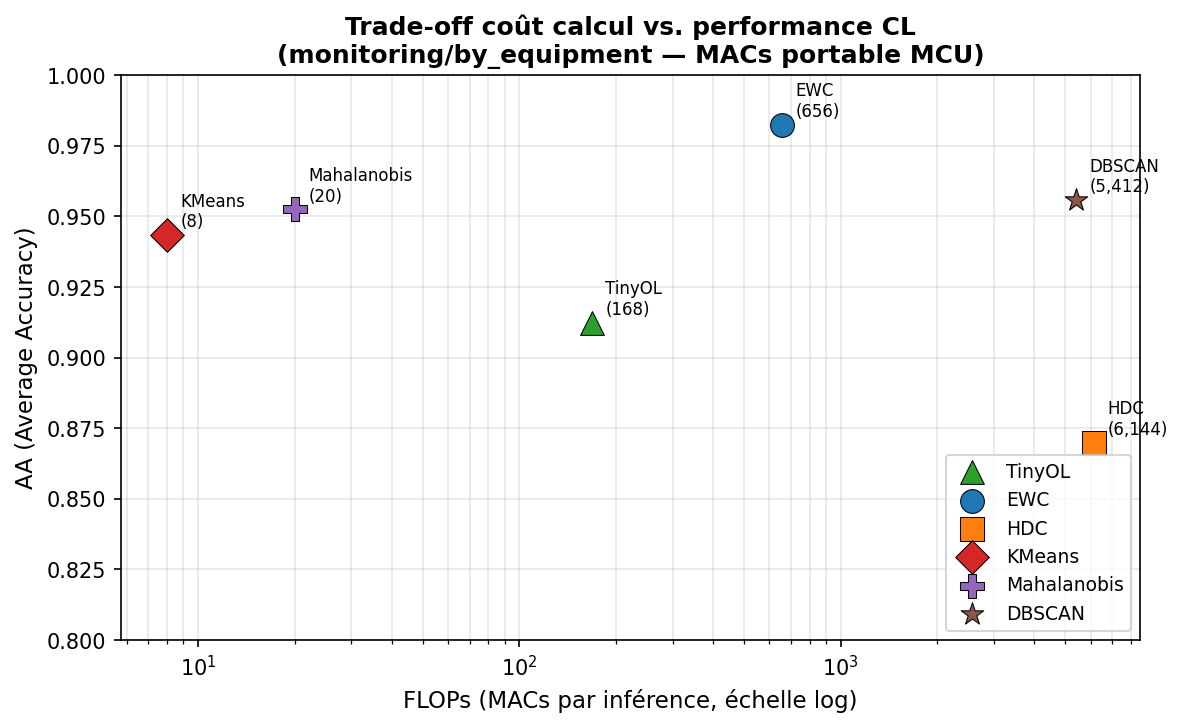

In [6]:
# Section 5b — Scatter FLOPs (MACs) vs. accuracy
# Coût de calcul portable — indépendant de la machine. Budget latence = 100 ms au MCU.

# MACs par inférence — calculés analytiquement (src.evaluation.compute_cost)
# k pour KMeans inféré depuis n_params : k = n_params / n_features
kmeans_k = max(1, results["KMeans"]["n_params"] // 4)
dbscan_n_core = max(1, results["DBSCAN"]["n_params"] // 4)

macs = {
    "EWC":         compute_macs("EWC",         n_features=4, hidden_dims=[32, 16], n_classes=1),
    "TinyOL":      compute_macs("TinyOL",      n_features=4, encoder_dims=[8, 8, 8], n_classes=1),
    "HDC":         compute_macs("HDC",         n_features=4, dim_hv=1024, n_classes=2),
    "KMeans":      compute_macs("KMeans",      n_features=4, n_clusters=kmeans_k),
    "Mahalanobis": compute_macs("Mahalanobis", n_features=4),
    "DBSCAN":      compute_macs("DBSCAN",      n_features=4, n_core_samples=dbscan_n_core),
}

fig, ax = plt.subplots(figsize=(8, 5))

for name in MODEL_ORDER:
    m = macs[name]
    acc = results[name]["aa"]
    marker, color = SCATTER_MARKERS[name]
    ax.scatter(m, acc, marker=marker, color=color, s=130, zorder=5, label=name,
               edgecolor="black", linewidth=0.5)
    ax.annotate(f"{name}\n({m:,})", xy=(m, acc), xytext=(m * 1.1, acc + 0.003),
                fontsize=8)

ax.set_xscale("log")
ax.set_xlabel("FLOPs (MACs par inférence, échelle log)", fontsize=11)
ax.set_ylabel("AA (Average Accuracy)", fontsize=11)
ax.set_title(
    "Trade-off coût calcul vs. performance CL\n(monitoring/by_equipment — MACs portable MCU)",
    fontsize=12, fontweight="bold",
)
ax.set_ylim(0.80, 1.0)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()

save_figure(fig, FIGURES_DIR / "scatter_flops_vs_accuracy.png")
display(Image(str(FIGURES_DIR / "scatter_flops_vs_accuracy.png")))

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/monitoring/by_equipment/scatter_latency_vs_accuracy.png


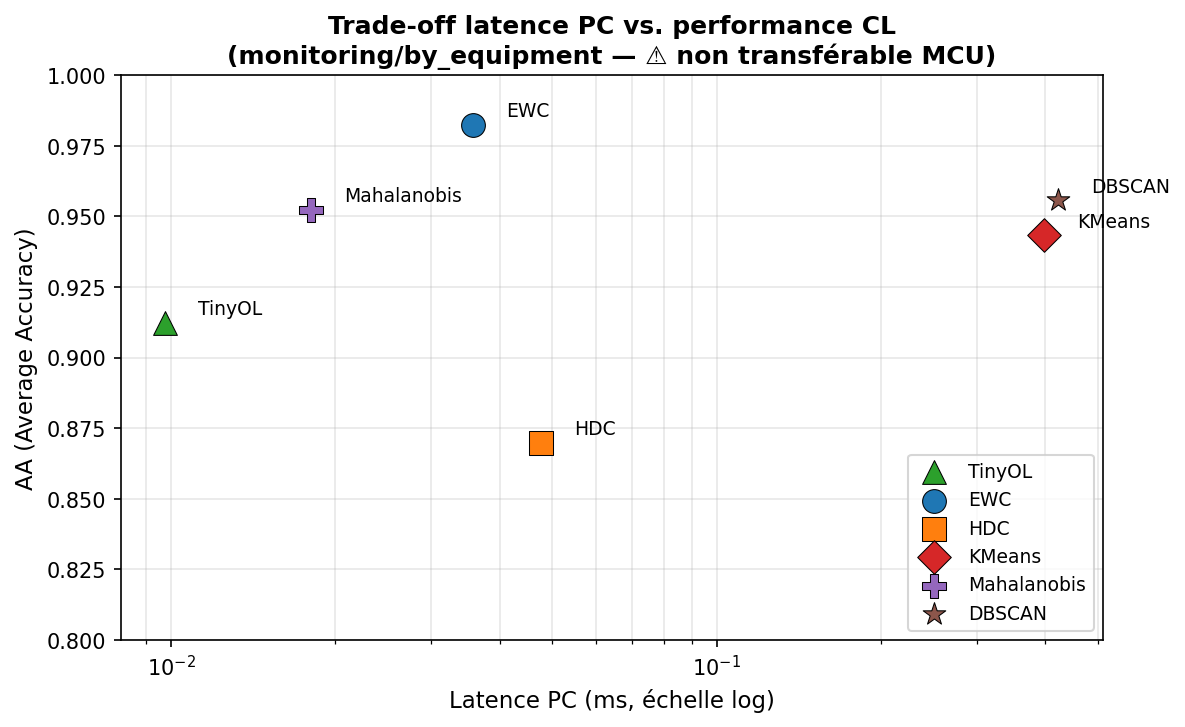

In [7]:
# Section 5c — Scatter latence PC vs. accuracy
# ⚠ Latence mesurée PC — non transférable directement au MCU (pas de NPU ici).
# Le budget 100 ms est le plafond STM32N6 (cf. CLAUDE.md).

LATENCY_BUDGET_MS = 100.0

fig, ax = plt.subplots(figsize=(8, 5))

for name in MODEL_ORDER:
    r = results[name]
    lat = r["inference_latency_ms"]
    acc = r["aa"]
    marker, color = SCATTER_MARKERS[name]
    ax.scatter(lat, acc, marker=marker, color=color, s=130, zorder=5, label=name,
               edgecolor="black", linewidth=0.5)
    ax.annotate(name, xy=(lat, acc), xytext=(lat * 1.15, acc + 0.003), fontsize=9)

ax.set_xscale("log")
ax.set_xlabel("Latence PC (ms, échelle log)", fontsize=11)
ax.set_ylabel("AA (Average Accuracy)", fontsize=11)
ax.set_title(
    "Trade-off latence PC vs. performance CL\n(monitoring/by_equipment — ⚠ non transférable MCU)",
    fontsize=12, fontweight="bold",
)
ax.set_ylim(0.80, 1.0)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()

save_figure(fig, FIGURES_DIR / "scatter_latency_vs_accuracy.png")
display(Image(str(FIGURES_DIR / "scatter_latency_vs_accuracy.png")))

In [8]:
# Section 6 — Tableau comparatif complet (6 modèles)

RAM_LIMIT = 64 * 1024

header = "| Modèle | AA ↑ | AF ↓ | BWT | AUROC | RAM | Latence | n_params | MACs |"
sep    = "|--------|:----:|:----:|:---:|:-----:|:---:|:-------:|:--------:|:----:|"

print(header)
print(sep)
rows_md = [header, sep]

for model in MODEL_ORDER:
    r = results[model]
    ram_b  = r["ram_peak_bytes"]
    ram_s  = f"{ram_b/1024:.1f} Ko{' ⚠️' if ram_b > RAM_LIMIT else ''}"
    auroc  = r["auroc_avg"]
    auroc_s = f"{auroc:.4f}" if isinstance(auroc, (int, float)) else "—"
    n_par  = r["n_params"] if r["n_params"] else "—"
    macs_m = macs.get(model, 0)
    line = (
        f"| {model} | {r['aa']:.4f} | {r['af']:.4f} | {r['bwt']:+.4f} | "
        f"{auroc_s} | {ram_s} | {r['inference_latency_ms']:.5f} ms | {n_par} | {macs_m:,} |"
    )
    print(line)
    rows_md.append(line)

display(Markdown("### Tableau récapitulatif — 6 modèles CL (monitoring/by_equipment)\n\n" +
                 "\n".join(rows_md)))

| Modèle | AA ↑ | AF ↓ | BWT | AUROC | RAM | Latence | n_params | MACs |
|--------|:----:|:----:|:---:|:-----:|:---:|:-------:|:--------:|:----:|
| TinyOL | 0.9123 | 0.0079 | -0.0029 | — | 4.3 Ko | 0.00975 ms | 194 | 168 |
| EWC | 0.9824 | 0.0010 | +0.0000 | — | 1.1 Ko | 0.03580 ms | 705 | 656 |
| HDC | 0.8698 | 0.0000 | +0.0019 | — | 14.2 Ko | 0.04758 ms | 2048 | 6,144 |
| KMeans | 0.9433 | 0.0049 | -0.0040 | 0.9621 | 5.2 Ko | 0.39870 ms | 8 | 8 |
| Mahalanobis | 0.9524 | 0.0010 | -0.0010 | 0.9718 | 1.5 Ko | 0.01801 ms | 20 | 20 |
| DBSCAN | 0.9557 | 0.0000 | +0.0010 | 0.9786 | 71.9 Ko ⚠️ | 0.42320 ms | 5412 | 5,412 |


### Tableau récapitulatif — 6 modèles CL (monitoring/by_equipment)

| Modèle | AA ↑ | AF ↓ | BWT | AUROC | RAM | Latence | n_params | MACs |
|--------|:----:|:----:|:---:|:-----:|:---:|:-------:|:--------:|:----:|
| TinyOL | 0.9123 | 0.0079 | -0.0029 | — | 4.3 Ko | 0.00975 ms | 194 | 168 |
| EWC | 0.9824 | 0.0010 | +0.0000 | — | 1.1 Ko | 0.03580 ms | 705 | 656 |
| HDC | 0.8698 | 0.0000 | +0.0019 | — | 14.2 Ko | 0.04758 ms | 2048 | 6,144 |
| KMeans | 0.9433 | 0.0049 | -0.0040 | 0.9621 | 5.2 Ko | 0.39870 ms | 8 | 8 |
| Mahalanobis | 0.9524 | 0.0010 | -0.0010 | 0.9718 | 1.5 Ko | 0.01801 ms | 20 | 20 |
| DBSCAN | 0.9557 | 0.0000 | +0.0010 | 0.9786 | 71.9 Ko ⚠️ | 0.42320 ms | 5412 | 5,412 |

## Discussion — monitoring_by_equipment

### Quel modèle a la meilleure accuracy sur ce scénario ?
**EWC** obtient le meilleur AA (0.9824), suivi de **DBSCAN** (0.9557), **Mahalanobis** (0.9524) et **KMeans** (0.9433).
**HDC** a l'AA le plus faible (0.8698) malgré un AF=0.0 par design.

### Quel modèle a le meilleur ratio performance/RAM ?
- **EWC** : AA=0.9824, RAM=1.1 Ko, latence=0.036 ms — **champion** tous critères confondus pour STM32N6.
- **Mahalanobis** : AA=0.9524, AUROC=0.9718, RAM=1.5 Ko, latence=0.018 ms — excellent 2e choix, non-supervisé.

Ces deux modèles sont les candidats les plus solides pour STM32N6 (Gap 2 respecté sans compromis).

### Y a-t-il de l'oubli catastrophique ?
Non — tous les modèles ont **AF < 0.01** sur ce scénario à 3 tâches.
HDC, DBSCAN et Mahalanobis (refit) atteignent AF=0.0 par construction.
TinyOL présente un léger oubli (AF=0.0079), EWC quasi-nul (AF=0.0010).

### Contrainte RAM STM32N6 (64 Ko)
| Modèle | RAM | Status |
|--------|-----|--------|
| EWC | 1.1 Ko | ✅ |
| Mahalanobis | 1.5 Ko | ✅ |
| TinyOL | 4.3 Ko | ✅ |
| KMeans | 5.2 Ko | ✅ |
| HDC | 14.2 Ko | ✅ |
| DBSCAN | 71.9 Ko | ❌ **FIXME(gap2)** — dépasse 64 Ko |

### Questions scientifiques ouvertes

- **FIXME(gap1)** : Ces résultats sur **données industrielles réelles** (equipment_monitoring, 7 672 échantillons,
  3 types d'équipements) comblent partiellement le Gap 1 de la littérature (validation industrielle réelle manquante
  dans la plupart des travaux CL+embarqué). À consolider avec le scénario `by_location` (S7-14) et Dataset 1 (Sprint 8).

- **FIXME(gap2)** : DBSCAN dépasse 64 Ko (71.9 Ko). Pistes : buffer borné de core points (top-500 → ~8 Ko),
  quantification INT8 des core points (÷4 empreinte), ou streaming DBSCAN incrémental.
  À planifier en Sprint 10 (portage MCU).

- **FIXME(gap3)** : Les modèles non-supervisés (KMeans, Mahalanobis, DBSCAN) ne nécessitent **pas de labels** —
  avantage industriel fort pour Edge Spectrum (maintenance prédictive sans annotation experte).
  La quantification INT8 pendant l'entraînement incrémental reste à valider (Sprint 9).

### Recommandation de déploiement

- **1er choix** — **EWC** : meilleure AA, meilleure empreinte mémoire, supervisé (nécessite labels).
- **2e choix** — **Mahalanobis** : non-supervisé, RAM minuscule, AUROC excellent. Adapté si pas de labels disponibles.
- **À étudier** — **TinyOL** : architecture modulaire (backbone gelé + tête OtO), intéressant pour l'extension future
  avec buffer UINT8 (Sprint 9, Objectif 1 étendu).

`TODO(arnaud)` : Valider cette recommandation avant la réunion d'encadrement.
`TODO(fred)` : Confronter la recommandation au contexte industriel Edge Spectrum (disponibilité des labels,
RAM effective des équipements cibles).